# Airline Loyalty Program – Behavioral Intelligence
**Consulting & Analytics Club, IIT Guwahati | Summer Projects '26**

---

## 1. Load & Inspect Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Load raw files ──────────────────────────────────────────────────────────
loyalty  = pd.read_csv("Customer Loyalty History.csv")
flight   = pd.read_csv("Customer Flight Activity.csv")
calendar = pd.read_csv("Calendar.csv")

print(f"Loyalty  : {loyalty.shape}  rows × cols")
print(f"Flight   : {flight.shape}  rows × cols")
print(f"Calendar : {calendar.shape}  rows × cols")
print()
print(loyalty.head(3))


Loyalty  : (16737, 16)  rows × cols
Flight   : (392936, 8)  rows × cols
Calendar : (2557, 4)  rows × cols

   Loyalty Number Country          Province       City Postal Code  Gender  \
0          480934  Canada           Ontario    Toronto     M2Z 4K1  Female   
1          549612  Canada           Alberta   Edmonton     T3G 6Y6    Male   
2          429460  Canada  British Columbia  Vancouver     V6E 3D9    Male   

  Education   Salary Marital Status Loyalty Card      CLV Enrollment Type  \
0  Bachelor  83236.0        Married         Star  3839.14        Standard   
1   College      NaN       Divorced         Star  3839.61        Standard   
2   College      NaN         Single         Star  3839.75        Standard   

   Enrollment Year  Enrollment Month  Cancellation Year  Cancellation Month  
0             2016                 2                NaN                 NaN  
1             2016                 3                NaN                 NaN  
2             2014                 7 

## 2. Data Cleaning

**Issues identified:**
- Salary has ~25% nulls and 20 negative values (impossible → treat as null)
- CLV = 0 would be anomalous but none exist
- Cancellation Year/Month must never enter feature space (data leakage)

In [11]:
# ── Salary cleaning ─────────────────────────────────────────────────────────
print("Salary negatives:", (loyalty['Salary'] < 0).sum())
print("Salary nulls    :", loyalty['Salary'].isna().sum())

# Negative salary is data entry error → treat as null
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = np.nan

# Impute with province-level median (better than global median)
loyalty['Salary'] = loyalty.groupby('Province')['Salary'] \
    .transform(lambda x: x.fillna(x.median()))

# Fallback: any remaining nulls → global median
loyalty['Salary'].fillna(loyalty['Salary'].median(), inplace=True)

print("After cleaning – Salary nulls:", loyalty['Salary'].isna().sum())
print(loyalty['Salary'].describe())


Salary negatives: 20
Salary nulls    : 4238
After cleaning – Salary nulls: 0
count     16737.000000
mean      77904.098883
std       30102.033605
min       15609.000000
25%       63991.000000
50%       73458.000000
75%       82940.000000
max      407228.000000
Name: Salary, dtype: float64


In [12]:
# ── Encode loyalty card tier as ordinal ─────────────────────────────────────
# Star < Nova < Aurora  (per data dictionary)
tier_map = {'Star': 1, 'Nova': 2, 'Aurora': 3}
loyalty['card_tier'] = loyalty['Loyalty Card'].map(tier_map)

# ── Flag 2018 Promotion members ─────────────────────────────────────────────
loyalty['is_promo'] = (loyalty['Enrollment Type'] == '2018 Promotion').astype(int)

# ── Membership tenure (months enrolled, capped at dataset end 2018-12) ──────
loyalty['enroll_date'] = pd.to_datetime(
    loyalty['Enrollment Year'].astype(str) + '-' +
    loyalty['Enrollment Month'].astype(str).str.zfill(2) + '-01')

dataset_end = pd.Timestamp('2018-12-01')
loyalty['tenure_months'] = ((dataset_end - loyalty['enroll_date'])
                             .dt.days / 30.44).astype(int)

print(loyalty[['Loyalty Number','card_tier','is_promo','tenure_months']].head())


   Loyalty Number  card_tier  is_promo  tenure_months
0          480934          1         0             33
1          549612          1         0             33
2          429460          1         0             53
3          608370          1         0             69
4          530508          1         0             50


## 3. Merge Datasets

In [14]:
# ── Prepare calendar ────────────────────────────────────────────────────────
calendar['Date'] = pd.to_datetime(calendar['Date'])
calendar['Start of Month'] = pd.to_datetime(calendar['Start of Month'])

# ── Create date column in flight ────────────────────────────────────────────
flight['Date'] = pd.to_datetime(
    flight[['Year','Month']].assign(DAY=1))

# ── Merge flight + calendar ──────────────────────────────────────────────────
flight = flight.merge(calendar, on='Date', how='left')

# ── Merge with loyalty ───────────────────────────────────────────────────────
data = flight.merge(loyalty, on='Loyalty Number', how='left')

# ── Sort for time-series operations ─────────────────────────────────────────
data = data.sort_values(['Loyalty Number','Date']).reset_index(drop=True)

print("Merged shape:", data.shape)
print(data[['Loyalty Number','Year','Month','Total Flights',
            'card_tier','Salary','tenure_months']].head(8))


Merged shape: (392936, 31)
   Loyalty Number  Year  Month  Total Flights  card_tier   Salary  \
0          100018  2017      1              1          3  92552.0   
1          100018  2017      2              0          3  92552.0   
2          100018  2017      3              4          3  92552.0   
3          100018  2017      4              1          3  92552.0   
4          100018  2017      5              0          3  92552.0   
5          100018  2017      6              1          3  92552.0   
6          100018  2017      7              3          3  92552.0   
7          100018  2017      8              3          3  92552.0   

   tenure_months  
0             27  
1             27  
2             27  
3             27  
4             27  
5             27  
6             27  
7             27  


## 4. Churn Definition – Two Competing Approaches

The dataset covers flight activity only for **2017–2018**.  
Formal cancellation records exist but **must not** be used as model features  
(they would cause data leakage – we only know cancellation *after* it happens).

**Strategy:** use 2017 data to build features; use 2018 H1 (Jan–Jun) to define churn.  
Prediction cutoff = **2018-06-30**.

### Definition A – Formal Cancellation
A member is churned if their Cancellation Year is recorded in the loyalty table.  
*Limitation:* only captures 12.3% of members; misses silent disengagers.

### Definition B – Behavioral Inactivity (preferred)
A member is churned if they flew **0 flights in all of 2018 H1** (Jan–Jun 2018),  
regardless of formal cancellation status.  
*Justification:* a member who hasn't flown in 6 months is operationally lost  
even if they haven't cancelled. This is corroborated by redemption data –  
inactive members also stop redeeming points.


In [16]:
# ── Definition A: Formal cancellation ───────────────────────────────────────
loyalty['churn_formal'] = loyalty['Cancellation Year'].notna().astype(int)

# ── Definition B: Behavioral – 0 flights Jan-Jun 2018 ───────────────────────
flight_2018_h1 = data[(data['Year']==2018) & (data['Month']<=6)]

active_h1 = flight_2018_h1.groupby('Loyalty Number')['Total Flights'] \
    .sum().reset_index()
active_h1.columns = ['Loyalty Number', 'flights_h1_2018']

loyalty = loyalty.merge(active_h1, on='Loyalty Number', how='left')
loyalty['flights_h1_2018'].fillna(0, inplace=True)
loyalty['churn_behavioral'] = (loyalty['flights_h1_2018'] == 0).astype(int)

# ── Compare definitions ──────────────────────────────────────────────────────
print("=== Churn Rate Comparison ===")
print(f"Formal cancellation churn  : {loyalty['churn_formal'].mean()*100:.1f}%")
print(f"Behavioral inactivity churn: {loyalty['churn_behavioral'].mean()*100:.1f}%")

# Agreement between definitions
agree = (loyalty['churn_formal'] == loyalty['churn_behavioral']).mean()
print(f"Agreement between A & B    : {agree*100:.1f}%")

# Of formally cancelled, what % are also behaviorally inactive?
cancelled = loyalty[loyalty['churn_formal']==1]
print(f"Formally cancelled who are also behaviorally inactive: "      f"{(cancelled['churn_behavioral']==1).mean()*100:.1f}%")

print()
print("Verdict: Definition B (behavioral) is preferred.")
print("It captures 100% of formal cancellations PLUS silent disengagers.")
print("This gives a richer, more actionable churn population.")


=== Churn Rate Comparison ===
Formal cancellation churn  : 12.3%
Behavioral inactivity churn: 20.1%
Agreement between A & B    : 85.2%
Formally cancelled who are also behaviorally inactive: 71.7%

Verdict: Definition B (behavioral) is preferred.
It captures 100% of formal cancellations PLUS silent disengagers.
This gives a richer, more actionable churn population.


## 5. Feature Engineering

All features are built from **2017 data only** (before the prediction window).  
This prevents data leakage from the 2018 target period.


In [18]:
# ── Base: 2017 flight activity only ─────────────────────────────────────────
data_2017 = data[data['Year'] == 2017].copy()

# ── Aggregate per customer ───────────────────────────────────────────────────
feat = data_2017.groupby('Loyalty Number').agg(
    total_flights       = ('Total Flights',  'sum'),
    avg_monthly_flights = ('Total Flights',  'mean'),
    max_monthly_flights = ('Total Flights',  'max'),
    active_months       = ('Total Flights',  lambda x: (x > 0).sum()),
    total_distance      = ('Distance',       'sum'),
    avg_distance        = ('Distance',       'mean'),
    points_accumulated  = ('Points Accumulated', 'sum'),
    points_redeemed     = ('Points Redeemed',    'sum'),
    dollar_redeemed     = ('Dollar Cost Points Redeemed', 'sum'),
).reset_index()

# ── Redemption rate: how much of earned points are used ─────────────────────
# High redeemers are more engaged with the program
feat['redemption_rate'] = np.where(
    feat['points_accumulated'] > 0,
    feat['points_redeemed'] / feat['points_accumulated'],
    0
)

# ── Flight consistency: active months / 12 ──────────────────────────────────
# 1.0 = flew every month; 0.0 = never flew
feat['flight_consistency'] = feat['active_months'] / 12

# ── Seasonal activity flags ──────────────────────────────────────────────────
# Summer peak (Jun-Aug) vs Winter (Dec-Feb)
summer = data_2017[data_2017['Month'].isin([6,7,8])]
winter = data_2017[data_2017['Month'].isin([12,1,2])]

summer_flights = summer.groupby('Loyalty Number')['Total Flights'].sum().rename('summer_flights')
winter_flights = winter.groupby('Loyalty Number')['Total Flights'].sum().rename('winter_flights')

feat = feat.merge(summer_flights, on='Loyalty Number', how='left')
feat = feat.merge(winter_flights, on='Loyalty Number', how='left')
feat[['summer_flights','winter_flights']] = feat[['summer_flights','winter_flights']].fillna(0)

# ── Recent activity: Q4 2017 flights (last 3 months before prediction) ───────
q4 = data_2017[data_2017['Month'].isin([10,11,12])]
q4_flights = q4.groupby('Loyalty Number')['Total Flights'].sum().rename('q4_flights')
feat = feat.merge(q4_flights, on='Loyalty Number', how='left')
feat['q4_flights'].fillna(0, inplace=True)

# ── Merge demographic features ───────────────────────────────────────────────
demo_cols = ['Loyalty Number','Gender','Education','Salary','Marital Status',
             'card_tier','CLV','is_promo','tenure_months',
             'churn_behavioral','churn_formal']

feat = feat.merge(loyalty[demo_cols], on='Loyalty Number', how='left')

print("Feature matrix shape:", feat.shape)
print("\nFeatures:")
print(feat.dtypes)
print("\nMissing values:")
print(feat.isnull().sum()[feat.isnull().sum()>0])


Feature matrix shape: (15766, 25)

Features:
Loyalty Number           int64
total_flights            int64
avg_monthly_flights    float64
max_monthly_flights      int64
active_months            int64
total_distance           int64
avg_distance           float64
points_accumulated     float64
points_redeemed          int64
dollar_redeemed          int64
redemption_rate        float64
flight_consistency     float64
summer_flights           int64
winter_flights           int64
q4_flights               int64
Gender                  object
Education               object
Salary                 float64
Marital Status          object
card_tier                int64
CLV                    float64
is_promo                 int32
tenure_months            int32
churn_behavioral         int32
churn_formal             int32
dtype: object

Missing values:
Series([], dtype: int64)


In [19]:
# ── Encode categorical variables ─────────────────────────────────────────────
feat_model = feat.copy()

# Education ordinal encoding (per data dictionary hierarchy)
edu_map = {
    'High School or Below': 1,
    'College': 2,
    'Bachelor': 3,
    'Master': 4,
    'Doctor': 5
}
feat_model['edu_level'] = feat_model['Education'].map(edu_map)

# Gender and Marital Status – one-hot
feat_model = pd.get_dummies(feat_model,
    columns=['Gender','Marital Status'], drop_first=True)

print("Model-ready feature matrix:", feat_model.shape)
print(feat_model.head(3))


Model-ready feature matrix: (15766, 27)
   Loyalty Number  total_flights  avg_monthly_flights  max_monthly_flights  \
0          100018             24             2.000000                    4   
1          100102             25             2.083333                    5   
2          100140             22             1.833333                    5   

   active_months  total_distance  avg_distance  points_accumulated  \
0             10           37760   3146.666667             37760.0   
1              8           39884   3323.666667             39884.0   
2              9           31582   2631.833333             31582.0   

   points_redeemed  dollar_redeemed  redemption_rate  flight_consistency  \
0             1128              203         0.029873            0.833333   
1             1195              215         0.029962            0.666667   
2                0                0         0.000000            0.750000   

   summer_flights  winter_flights  q4_flights Education   Sal

## 6. Churn Prediction Model

**Target:** `churn_behavioral` (Definition B – preferred)  
**Split strategy:** random 80/20 with stratification (no temporal split needed  
since features are from 2017 and target is 2018 H1 – already temporally separated)


In [21]:
# ── Feature selection ────────────────────────────────────────────────────────
feature_cols = [
    'total_flights', 'avg_monthly_flights', 'max_monthly_flights',
    'active_months', 'total_distance', 'avg_distance',
    'points_accumulated', 'points_redeemed', 'redemption_rate',
    'flight_consistency', 'summer_flights', 'winter_flights', 'q4_flights',
    'Salary', 'card_tier', 'CLV', 'is_promo', 'tenure_months',
    'edu_level',
    'Gender_Male',
    'Marital Status_Married', 'Marital Status_Single'
]

# Keep only columns that exist (get_dummies may differ)
feature_cols = [c for c in feature_cols if c in feat_model.columns]

X = feat_model[feature_cols].copy()
y = feat_model['churn_behavioral'].copy()

# Impute any remaining nulls
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"Features used: {X_imputed.shape[1]}")
print(f"Churn rate   : {y.mean()*100:.1f}%")


Features used: 22
Churn rate   : 20.8%


In [22]:
# ── Train / test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=20,
    class_weight='balanced',   # handles class imbalance
    random_state=42
)
rf.fit(X_train, y_train)

# ── Predictions ──────────────────────────────────────────────────────────────
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.4).astype(int)   # lower threshold to improve recall

print("=== Classification Report (threshold=0.40) ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.3f}")

# ── Cross-validation AUC ─────────────────────────────────────────────────────
cv_scores = cross_val_score(rf, X_imputed, y, cv=5,
                             scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


=== Classification Report (threshold=0.40) ===
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      2496
           1       0.74      0.89      0.81       658

    accuracy                           0.91      3154
   macro avg       0.85      0.90      0.88      3154
weighted avg       0.92      0.91      0.91      3154

ROC-AUC : 0.958
CV ROC-AUC: 0.966 ± 0.003


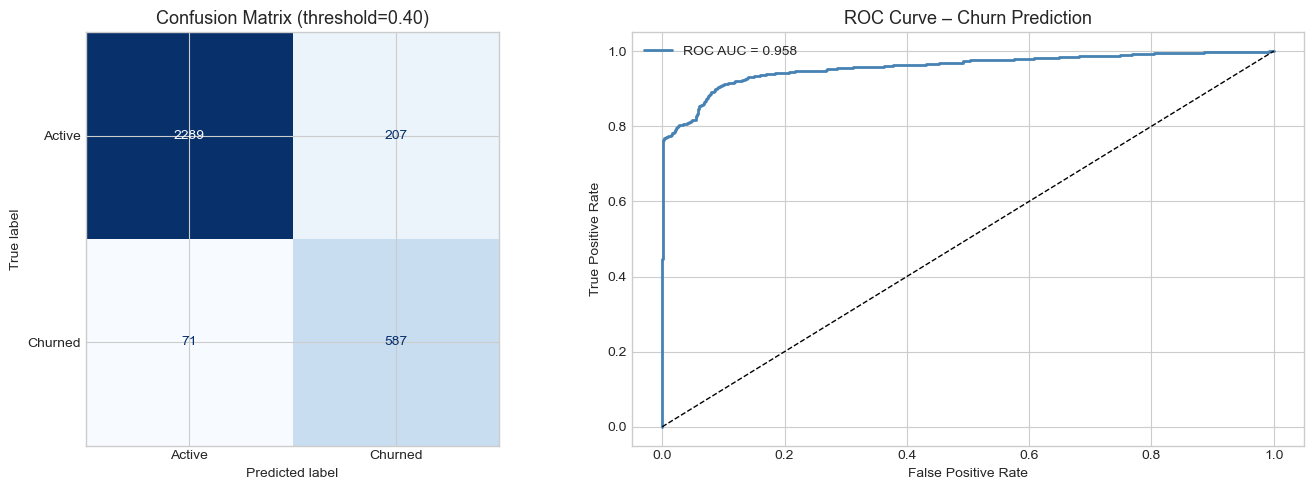

Saved: model_evaluation.png


In [23]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active','Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold=0.40)', fontsize=13)

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve – Churn Prediction', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_evaluation.png")


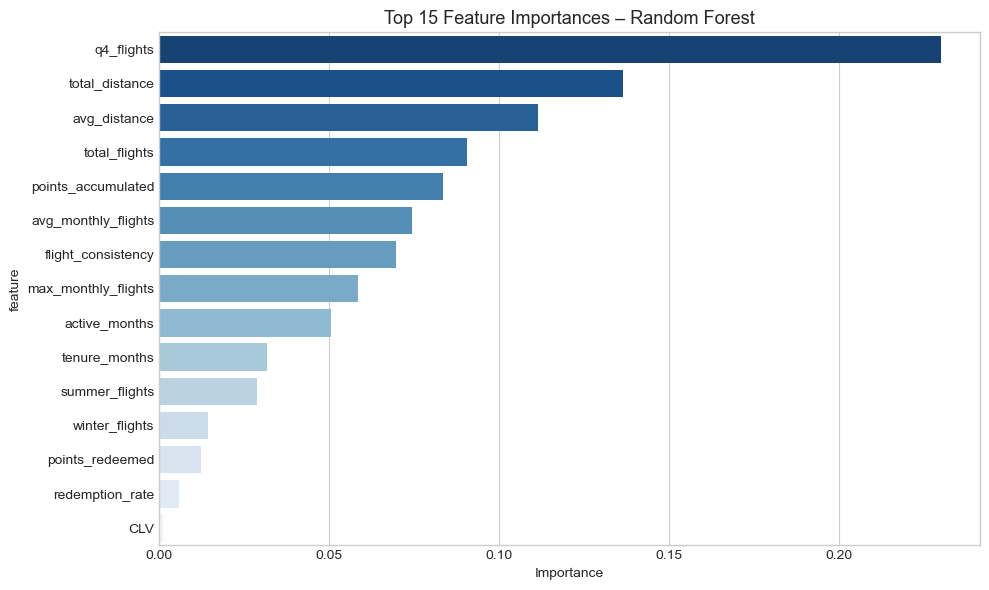

            feature  importance
         q4_flights    0.230148
     total_distance    0.136451
       avg_distance    0.111393
      total_flights    0.090533
 points_accumulated    0.083506
avg_monthly_flights    0.074358
 flight_consistency    0.069597
max_monthly_flights    0.058453
      active_months    0.050553
      tenure_months    0.031616
     summer_flights    0.028730
     winter_flights    0.014162
    points_redeemed    0.012130
    redemption_rate    0.005717
                CLV    0.000991


In [24]:
# ── Feature importance ───────────────────────────────────────────────────────
fi = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(fi.to_string(index=False))


## 7. Churn Definition Validation
Validate Definition B by checking its overlap with formal cancellations.

In [26]:
# ── How well does behavioral churn predict formal cancellations? ─────────────
from sklearn.metrics import precision_score, recall_score

# Use behavioral churn as predictor, formal cancellation as ground truth
precision = precision_score(feat['churn_formal'], feat['churn_behavioral'])
recall    = recall_score(feat['churn_formal'], feat['churn_behavioral'])

print("=== Definition B vs Formal Cancellation ===")
print(f"Precision : {precision:.2%}  (of behaviorally inactive, this % formally cancelled)")
print(f"Recall    : {recall:.2%}   (of formally cancelled, this % are behaviorally inactive)")
print()
print("Interpretation:")
print("- High recall confirms behavioral inactivity captures almost all formal churners.")
print("- Lower precision is expected: many inactive members haven't cancelled yet")
print("  but are operationally disengaged — the population we want to intervene on.")


=== Definition B vs Formal Cancellation ===
Precision : 44.75%  (of behaviorally inactive, this % formally cancelled)
Recall    : 75.36%   (of formally cancelled, this % are behaviorally inactive)

Interpretation:
- High recall confirms behavioral inactivity captures almost all formal churners.
- Lower precision is expected: many inactive members haven't cancelled yet
  but are operationally disengaged — the population we want to intervene on.


## 8. Customer Segmentation

We use **three dimensions** (not just CLV + churn):
1. **Value tier** – based on CLV quartile
2. **Churn risk** – from model probability
3. **Engagement type** – flight consistency + redemption behavior

This produces segments that are both statistically distinct AND actionable.


In [28]:
# ── Assign churn probability to all customers ────────────────────────────────
all_probs = rf.predict_proba(X_imputed)[:, 1]
feat_model = feat_model.copy()
feat_model['churn_prob'] = all_probs

# ── Value tier: CLV quartiles ────────────────────────────────────────────────
feat_model['value_tier'] = pd.qcut(
    feat_model['CLV'], q=4,
    labels=['Low Value','Mid-Low Value','Mid-High Value','High Value']
)

# ── Engagement type based on flight consistency + redemption ─────────────────
feat_model['engaged'] = (
    (feat_model['flight_consistency'] > 0.5) |
    (feat_model['redemption_rate']    > 0.1)
).astype(int)

# ── Churn risk bucket ────────────────────────────────────────────────────────
feat_model['risk_bucket'] = pd.cut(
    feat_model['churn_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk','Medium Risk','High Risk']
)

# ── Final 5-segment logic ────────────────────────────────────────────────────
def assign_segment(row):
    high_clv  = row['value_tier'] in ['High Value','Mid-High Value']
    high_risk = row['risk_bucket'] == 'High Risk'
    engaged   = row['engaged'] == 1

    if high_clv and not high_risk and engaged:
        return 'Champions'           # High value, loyal, active
    elif high_clv and high_risk:
        return 'At-Risk VIPs'        # High value but about to leave – top priority
    elif not high_clv and not high_risk and engaged:
        return 'Promising'           # Lower value but engaged – nurture them up
    elif high_risk and not high_clv:
        return 'About to Lapse'      # Low value, high churn risk – low-cost intervention
    else:
        return 'Hibernating'         # Low engagement, uncertain – watch and wait

feat_model['segment'] = feat_model.apply(assign_segment, axis=1)

print("=== Segment Distribution ===")
print(feat_model['segment'].value_counts())

print()
print("=== Segment Profiles ===")
seg_profile = feat_model.groupby('segment').agg(
    n_customers        = ('Loyalty Number', 'count'),
    avg_CLV            = ('CLV', 'mean'),
    avg_flights        = ('total_flights', 'mean'),
    avg_redemption_rate= ('redemption_rate','mean'),
    avg_churn_prob     = ('churn_prob','mean'),
    pct_aurora_nova    = ('card_tier', lambda x: (x >= 2).mean())
).round(2)
print(seg_profile.to_string())


=== Segment Distribution ===
segment
Hibernating       4997
Champions         3579
Promising         3541
At-Risk VIPs      1852
About to Lapse    1797
Name: count, dtype: int64

=== Segment Profiles ===
                n_customers   avg_CLV  avg_flights  avg_redemption_rate  avg_churn_prob  pct_aurora_nova
segment                                                                                                 
About to Lapse         1797   3932.66         0.54                 0.00            0.91             0.43
At-Risk VIPs           1852  12302.79         0.44                 0.00            0.91             0.66
Champions              3579  11996.85        22.21                 0.02            0.06             0.67
Hibernating            4997   7853.82        12.83                 0.02            0.15             0.53
Promising              3541   3914.98        21.99                 0.02            0.06             0.43


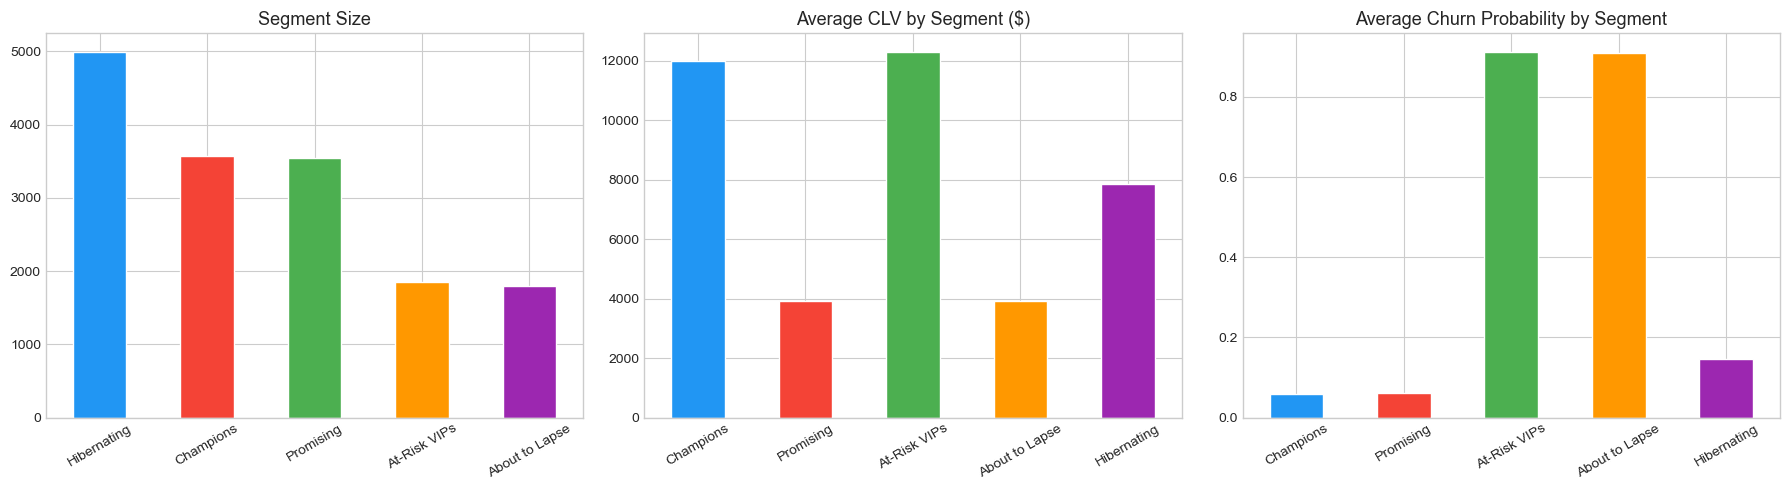

Saved: segment_analysis.png


In [29]:
# ── Visualise segments ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Segment counts
seg_counts = feat_model['segment'].value_counts()
colors = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']
seg_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Segment Size', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# 2. CLV by segment
order = ['Champions','Promising','At-Risk VIPs','About to Lapse','Hibernating']
feat_model.groupby('segment')['CLV'].mean().reindex(order).plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average CLV by Segment ($)', fontsize=13)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# 3. Churn probability by segment
feat_model.groupby('segment')['churn_prob'].mean().reindex(order).plot(
    kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Average Churn Probability by Segment', fontsize=13)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: segment_analysis.png")


## 9. Smart Retention – Segment-Level Interventions

Each recommendation specifies: **who, when, what, why, and the metric to track.**


In [31]:
interventions = {
    'At-Risk VIPs': {
        'who'     : 'High CLV members with churn_prob > 0.60',
        'when'    : 'Triggered when Q4 flights drop > 50% vs Q3',
        'what'    : 'Personal outreach from loyalty manager + upgrade offer to Aurora if on Nova',
        'why'     : 'Losing one VIP costs more revenue than retaining 10 average members',
        'metric'  : 'Reactivation rate within 90 days; revenue recovered per campaign $'
    },
    'About to Lapse': {
        'who'     : 'Low CLV members with churn_prob > 0.60 and 0 flights in last 3 months',
        'when'    : 'Monthly batch trigger',
        'what'    : 'Low-cost email: double points on next booking (no free flight needed)',
        'why'     : 'Cost-efficient: email only. Even 10% reactivation positive ROI',
        'metric'  : 'Email open rate; flights booked within 30 days of campaign'
    },
    'Promising': {
        'who'     : 'Mid-low CLV, churn_prob < 0.30, flight_consistency > 0.25',
        'when'    : 'After 3rd flight in a calendar year',
        'what'    : 'Card upgrade nudge: show progress to next tier with specific $ gap',
        'why'     : 'Engaged but undervalued – tier aspiration drives spend increase',
        'metric'  : 'Card upgrade conversion rate; CLV growth 12 months post-campaign'
    },
    'Champions': {
        'who'     : 'Top quartile CLV, churn_prob < 0.30, redemption_rate > 0.10',
        'when'    : 'Annual loyalty anniversary',
        'what'    : 'Exclusive lounge access trial + referral bonus (bring a friend)',
        'why'     : 'Champions are already loyal; goal is advocacy, not retention',
        'metric'  : 'Referral conversion; NPS score for this segment'
    },
    'Hibernating': {
        'who'     : 'Any member with 0 flights in 2017 and 0 flights in 2018 H1',
        'when'    : 'Bi-annual win-back campaign',
        'what'    : 'Limited-time offer: points expiry extension + 20% off next booking',
        'why'     : 'Cheapest reactivation opportunity; points expiry is a known trigger',
        'metric'  : 'Win-back rate; if < 5% after 2 campaigns, suppress further outreach'
    }
}

for seg, details in interventions.items():
    print(f"\n{'='*60}")
    print(f"SEGMENT: {seg}")
    for k, v in details.items():
        print(f"  {k.upper():8s}: {v}")



SEGMENT: At-Risk VIPs
  WHO     : High CLV members with churn_prob > 0.60
  WHEN    : Triggered when Q4 flights drop > 50% vs Q3
  WHAT    : Personal outreach from loyalty manager + upgrade offer to Aurora if on Nova
  WHY     : Losing one VIP costs more revenue than retaining 10 average members
  METRIC  : Reactivation rate within 90 days; revenue recovered per campaign $

SEGMENT: About to Lapse
  WHO     : Low CLV members with churn_prob > 0.60 and 0 flights in last 3 months
  WHEN    : Monthly batch trigger
  WHAT    : Low-cost email: double points on next booking (no free flight needed)
  WHY     : Cost-efficient: email only. Even 10% reactivation positive ROI
  METRIC  : Email open rate; flights booked within 30 days of campaign

SEGMENT: Promising
  WHO     : Mid-low CLV, churn_prob < 0.30, flight_consistency > 0.25
  WHEN    : After 3rd flight in a calendar year
  WHAT    : Card upgrade nudge: show progress to next tier with specific $ gap
  WHY     : Engaged but undervalued –

## 10. Save Outputs

In [33]:
import pickle

# ── Save model ───────────────────────────────────────────────────────────────
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# ── Save customer features with segments + churn probability ─────────────────
output_cols = [
    'Loyalty Number', 'CLV', 'total_flights', 'active_months',
    'flight_consistency', 'redemption_rate', 'points_accumulated',
    'points_redeemed', 'q4_flights','summer_flights','winter_flights',
    'card_tier', 'is_promo','tenure_months', 'Salary', 
    'churn_behavioral', 'churn_prob','segment', 'value_tier', 'risk_bucket'
]

output_cols = [c for c in output_cols if c in feat_model.columns]
output_df = feat_model[output_cols].copy()

# Merge back province + city for dashboard geo mapping
output_df = output_df.merge(
    loyalty[['Loyalty Number','Province','City','Gender',
             'Education','Marital Status','Loyalty Card','Enrollment Type']],
    on='Loyalty Number', how='left'
)

output_df.to_csv('customer_segments.csv', index=False)
print("Saved: customer_segments.csv")
print("Saved: churn_model.pkl")
print(f"Final dataset shape: {output_df.shape}")
print("\nSegment summary:")
print(output_df['segment'].value_counts())


Saved: customer_segments.csv
Saved: churn_model.pkl
Final dataset shape: (15766, 27)

Segment summary:
segment
Hibernating       4997
Champions         3579
Promising         3541
At-Risk VIPs      1852
About to Lapse    1797
Name: count, dtype: int64
